In [1]:
import torch 
from src.utils import DataType, NeuralOperatorDataset
import json
from src.models import NeuralOperatorModel, ModelType

import matplotlib.pyplot as plt


In [2]:
from src.utils import LpLoss


model_name = "un_Darcy2D_nl1_long_wfix"

with open(f'./models/{model_name}.json') as f:
    d = json.load(f)

print(d)

data_type = DataType(d["data"])
cheby = False if d["model"] == "fno" else True
data = NeuralOperatorDataset(data_type, 
                            is_cheby=cheby, 
                            ntrain=d["ntrain"],
                            ntest=d["ntest"], 
                            batch_size=d["ntest"], # Can grab entire dataset
                            normalize=d["normalize"],
                            subsample=d["subsample"])


loss_fn = LpLoss(size_average=False, reduction=False).rel_no_reduction

model_params = {k: eval(v) for k, v in (arg.split('=') for arg in d["arg"])}
model = NeuralOperatorModel(ModelType(d["model"]), data=data_type, **model_params)

model.load_state_dict(torch.load(f"./models/{model_name}.pt", map_location=torch.device('cpu')))


{'model': 'ultranet', 'data': 'darcy2d', 'run_name': 'un_Darcy2D_nl1_long_wfix', 'project_name': 'Darcy2D_Neumann', 'subsample': 1, 'arg': ['modes=[12,12]', 'width=9', 'rank=4', 'nlayers=1'], 'nepochs': 5000, 'step_size': 500, 'lr': 0.01, 'ntrain': 1000, 'ntest': 200, 'batch_size': 4, 'normalize': False, 'nparams': 293135}


<All keys matched successfully>

a.shape:  torch.Size([1, 128, 128, 3])
u.shape:  torch.Size([1, 128, 128, 1])
grid.shape:  torch.Size([128, 128, 2])
out.shape:  torch.Size([1, 128, 128, 1])
error.shape:  torch.Size([1, 128, 128])


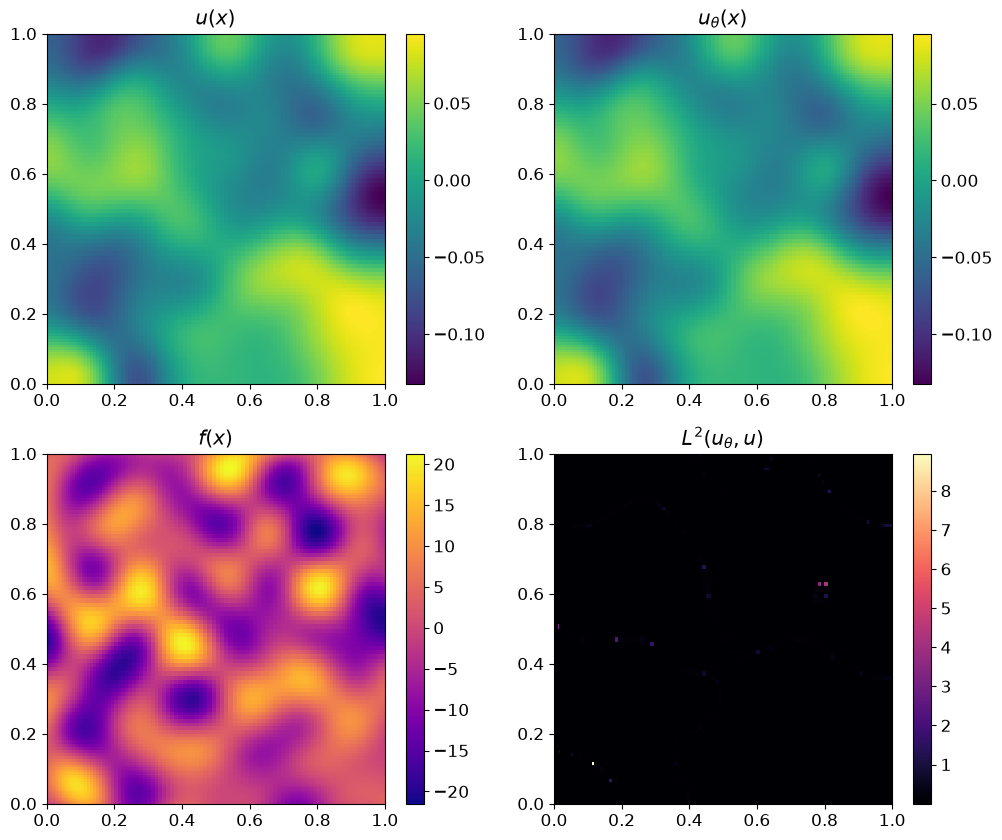

In [3]:
from src.utils.data import generate_grid

plt.rcParams.update({'font.size': 12}) 


def visualize_output(model: NeuralOperatorModel, data: NeuralOperatorDataset):
    a, u = next(iter(data.test_loader))
    idx = 0
    a, u = a[idx:idx+1], u[idx:idx+1]
    grid = (a[0, ... , 1:] + 1) * 0.5 
    out = model(a)
    error = loss_fn(out, u)

    out = out.detach()
    error = error.detach()
    print("a.shape: ", a.shape)
    print("u.shape: ", u.shape)
    print("grid.shape: ", grid.shape)
    print("out.shape: ", out.shape)
    print("error.shape: ", error.shape)
    
    if data.cfg.d == 1:
        fig, axs = plt.subplots(1, 1, figsize=(6, 6))
        markevery = 3
        axs.plot(grid, a[0, ..., 0], '-.', ms=8, markevery=markevery, label=r'$u(x, 0)$')
        axs.plot(grid, u[0], 'r', ls="-", linewidth=5, markevery=markevery+1, label=r'$u(x, 1)$')
        axs.plot(grid, out[0], 'g', ls="-", ms=4, markevery=markevery, label=r'$u_\theta(x, 1)$')
        plt.legend()
        plt.show()
    
    if data.cfg.d == 2:

        if data.cfg.o_d == 1:

            fig, axs = plt.subplots(2, 2, figsize=(12, 10))

            im1 = axs[0][0].pcolormesh(grid[..., 0], grid[..., 1], u[0, ..., 0], cmap='viridis', linewidth=0.5)
            fig.colorbar(im1, ax=axs[0, 0])
            axs[0][0].set_title(r"$u(x)$")

            im2 = axs[0][1].pcolormesh(grid[..., 0], grid[..., 1], out[0, ..., 0], cmap='viridis', linewidth=0.5)
            fig.colorbar(im2, ax=axs[0, 1])
            axs[0][1].set_title(r"$u_\theta(x)$")

            im0 = axs[1][0].pcolormesh(grid[..., 0], grid[..., 1], a[0, ..., 0], cmap='plasma', linewidth=0.5)
            fig.colorbar(im0, ax=axs[1, 0])
            axs[1][0].set_title(r"$f(x)$")

            im3 = axs[1][1].pcolormesh(grid[..., 0], grid[..., 1], error[0], cmap='magma', linewidth=0.5)
            fig.colorbar(im3, ax=axs[1, 1])
            axs[1][1].set_title(r"$L^2(u_\theta, u)$")

            plt.show()

        elif data.cfg.o_d == 2:

            fig, axs = plt.subplots(2, 3, figsize=(16, 8))

            im1 = axs[0][0].pcolormesh(grid[..., 0], grid[..., 1], u[0, ..., 0], cmap='viridis', linewidth=0.5)
            fig.colorbar(im1, ax=axs[0, 0])
            axs[0][0].set_title(r"$u(x)_{real}$")

            im1 = axs[0][1].pcolormesh(grid[..., 0], grid[..., 1], u[0, ..., 1], cmap='viridis', linewidth=0.5)
            fig.colorbar(im1, ax=axs[0, 1])
            axs[0][1].set_title(r"$u(x)_{imag}$")

            im2 = axs[1][0].pcolormesh(grid[..., 0], grid[..., 1], out[0, ..., 0], cmap='viridis', linewidth=0.5)
            fig.colorbar(im2, ax=axs[1, 0])
            axs[1][0].set_title(r"$u_{\theta, real}(x)$")

            im2 = axs[1][1].pcolormesh(grid[..., 0], grid[..., 1], out[0, ..., 1], cmap='viridis', linewidth=0.5)
            fig.colorbar(im2, ax=axs[1, 1])
            axs[1][1].set_title(r"$u_{\theta, imag}(x)$")

            im0 = axs[0][2].pcolormesh(grid[..., 0], grid[..., 1], a[0, ..., 0], cmap='plasma', linewidth=0.5)
            fig.colorbar(im0, ax=axs[0, 2])
            axs[0][2].set_title(r"$f(x)$")

            im0 = axs[1][2].pcolormesh(grid[..., 0], grid[..., 1], error[0], cmap='magma', linewidth=0.5)
            fig.colorbar(im0, ax=axs[1, 2])
            axs[1][2].set_title(r"$L^2(u_\theta, u)$")
            plt.show()

visualize_output(model, data=data)


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jensnielsen/.netrc.


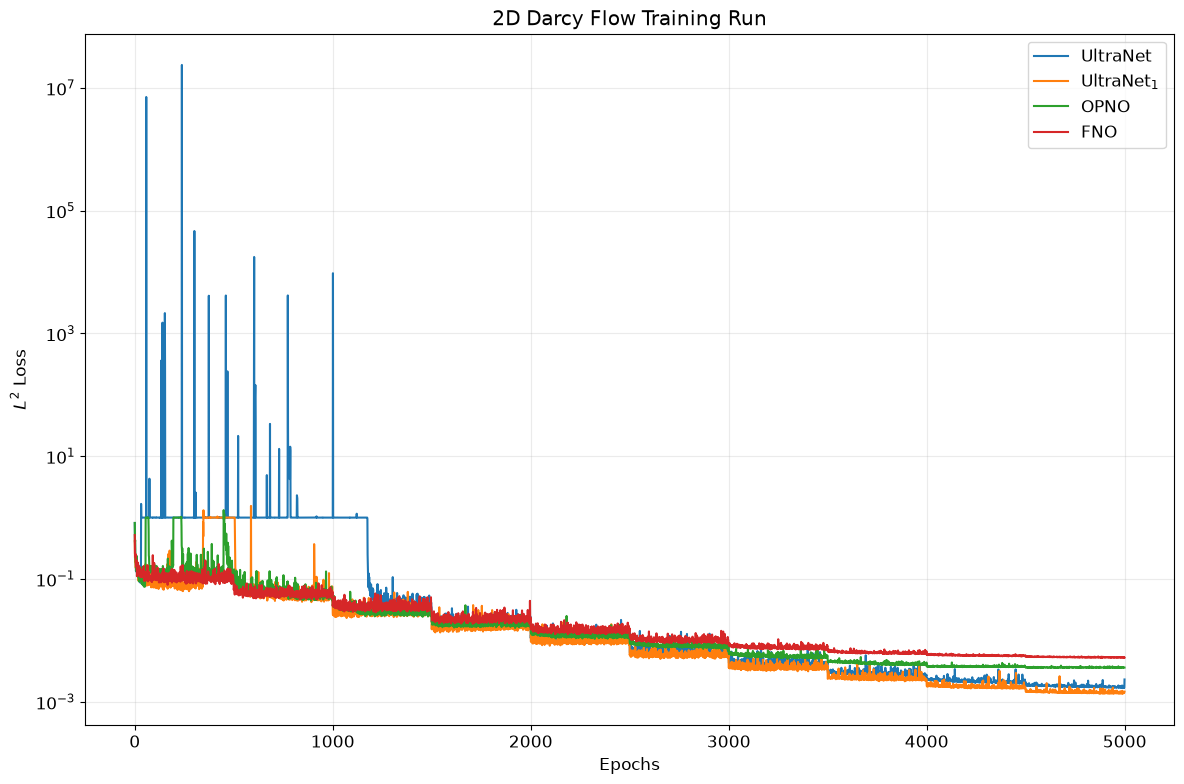

In [4]:

def get_run_history(api, run_path, metric="loss"):
    """Download metric history from a W&B run."""
    run = api.run(run_path)

    history = run.scan_history(keys=[metric, "_step"])

    steps = []
    losses = []

    for row in history:
        if metric in row and row[metric] is not None:
            steps.append(row.get("_step", len(steps)))
            losses.append(row[metric])

    if not losses:
        raise RuntimeError(f"No '{metric}' values found for {run_path}")

    return run.name, steps, losses



import wandb
api = wandb.Api()
metric = "Test L2"

# Helmholtz 2D
h2d_runs = [
    "jens1225-eth-zrich/UNH2DLong/mhxwjcld",
    "jens1225-eth-zrich/UNH2DLong/1f90j9tx",
    "jens1225-eth-zrich/UNH2DLong/spbkygw4",
    "jens1225-eth-zrich/UNH2DLong/0ivf7z64"
]

# Darcy2D
darcy2d_runs = [
    "jens1225-eth-zrich/Darcy2D_Neumann/yx3ywj9b",
    "jens1225-eth-zrich/Darcy2D_Neumann/rczwo7jm",
    "jens1225-eth-zrich/Darcy2D_Neumann/7ddf71i5",
    "jens1225-eth-zrich/Darcy2D_Neumann/xx211c8e"
]

darcy1d_500_runs = [
    "jens1225-eth-zrich/ultranet_darcy_neumann/ijawwy53",
    "jens1225-eth-zrich/ultranet_darcy_neumann/vb3pehbf",
    "jens1225-eth-zrich/ultranet_darcy_neumann/l14sk2xv"
]

burger_500_runs = [
    "jens1225-eth-zrich/ultranet_neumann_sweep/q9cnt68u",
    "jens1225-eth-zrich/ultranet_neumann_sweep/17kphfk3",
    "jens1225-eth-zrich/ultranet_neumann_sweep/88d0fijf"
]

names = [
    "UltraNet",
    r"UltraNet$_1$",
    "OPNO",
    "FNO"
]

runs = darcy2d_runs

plt.figure(figsize=(12, 8))

for run_path, name in zip(runs, names):
    _, steps, values = get_run_history(
        api, run_path, metric=metric
    )

    plt.plot(
        steps,
        values,
        label=name,
        linewidth=1.5,
    )


plt.xlabel("Epochs")
plt.ylabel(r"$L^2$ Loss")
plt.title("2D Darcy Flow Training Run")
plt.grid(True, alpha=0.25)
plt.yscale("log")
plt.legend()
plt.tight_layout()

plt.show()